# Аналитика: рецепты «Поварёнок»

Смотрим на датасет [rogozinushka/povarenok-recipes](https://huggingface.co/datasets/rogozinushka/povarenok-recipes), на котором построены рекомендации в этом семинаре: сколько ингредиентов бывает в рецепте, какие ингредиенты встречаются чаще всего и как они соседствуют друг с другом. 

In [1]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.prepare_data import build_clean_dataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
BAR_COLOR = "#4C72B0"

In [2]:
recipes = build_clean_dataset()
print("Рецептов:", len(recipes))
recipes.head(3)

Рецептов: 146370


## Сколько ингредиентов в рецепте

count    146370.000000
mean          8.748815
std           3.112650
min           1.000000
25%           7.000000
50%           9.000000
75%          11.000000
max          31.000000
Name: ingredients, dtype: float64


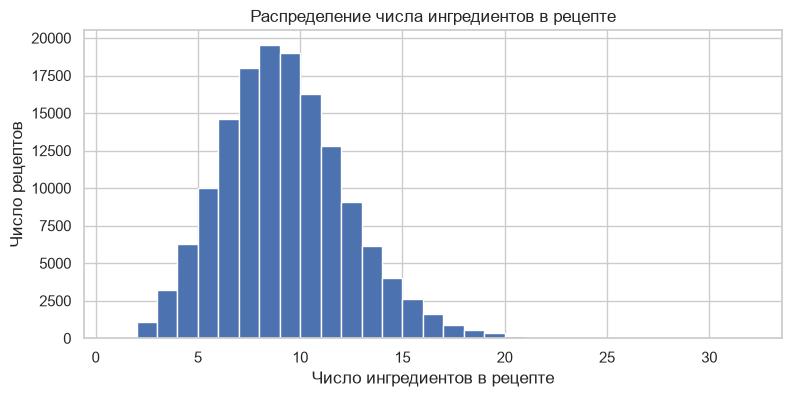

In [3]:
ingredient_counts = recipes["ingredients"].apply(len)
display(ingredient_counts.describe())

plt.hist(ingredient_counts, bins=range(1, ingredient_counts.max() + 2), color=BAR_COLOR)
plt.xlabel("Число ингредиентов в рецепте")
plt.ylabel("Число рецептов")
plt.title("Распределение числа ингредиентов в рецепте")
plt.show()

## Самые популярные ингредиенты

Топ-20 ингредиентов по числу рецептов, в которых они встречаются.

Уникальных ингредиентов: 908


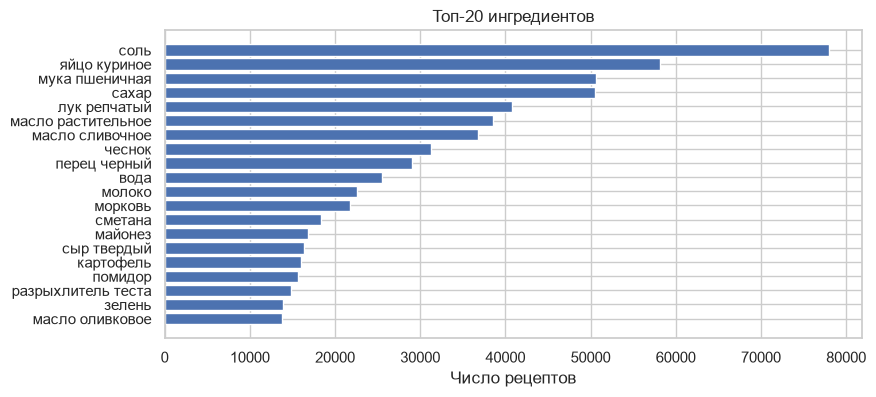

In [4]:
ingredient_frequency = Counter(
    ingredient for ingredients in recipes["ingredients"] for ingredient in ingredients
)
print("Уникальных ингредиентов:", len(ingredient_frequency))

top_ingredients = pd.Series(ingredient_frequency).sort_values(ascending=False).head(20)

plt.barh(top_ingredients.index[::-1], top_ingredients.values[::-1], color=BAR_COLOR)
plt.xlabel("Число рецептов")
plt.title("Топ-20 ингредиентов")
plt.show()

## Длинный хвост популярности

Как и в большинстве датасетов рекомендательных систем (см. семинар 1), популярность ингредиентов распределена очень неравномерно: малая доля ингредиентов встречается в огромном числе рецептов, а у длинного хвоста — единичные упоминания.

Доля ингредиентов, встретившихся только в одном рецепте: 0.0%


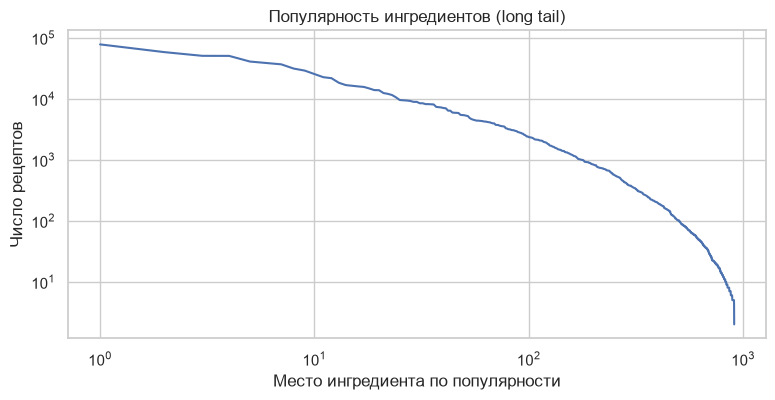

In [5]:
popularity = pd.Series(ingredient_frequency).sort_values(ascending=False)

plt.plot(np.arange(1, len(popularity) + 1), popularity.values, color=BAR_COLOR)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Место ингредиента по популярности")
plt.ylabel("Число рецептов")
plt.title("Популярность ингредиентов (long tail)")
plt.show()

rare_share = (popularity == 1).mean()
print(f"Доля ингредиентов, встретившихся только в одном рецепте: {rare_share:.1%}")

## С чем чаще всего соседствует ингредиент

Простое совместное появление (co-occurrence) ингредиентов в одном рецепте — та же идея, что лежит в основе рекомендателя из `src/recommender.py`: чем чаще два ингредиента встречаются вместе, тем «ближе» они друг к другу.

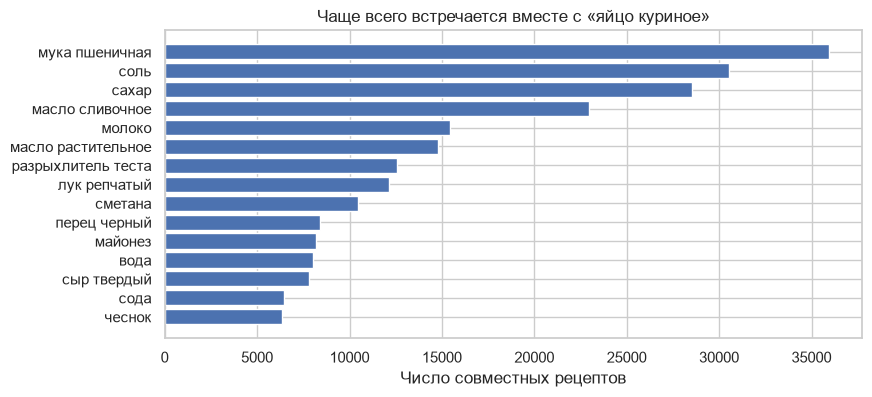

In [6]:
def top_co_occurring(recipes: pd.DataFrame, ingredient: str, top_k: int = 15) -> pd.Series:
    co_occurrence = Counter()
    for ingredients in recipes["ingredients"]:
        if ingredient in ingredients:
            co_occurrence.update(other for other in ingredients if other != ingredient)
    return pd.Series(co_occurrence).sort_values(ascending=False).head(top_k)


target_ingredient = "яйцо куриное"
neighbors = top_co_occurring(recipes, target_ingredient)

plt.barh(neighbors.index[::-1], neighbors.values[::-1], color=BAR_COLOR)
plt.xlabel("Число совместных рецептов")
plt.title(f'Чаще всего встречается вместе с «{target_ingredient}»')
plt.show()